# 📘 Dataset Tutorial Notebook


## ⚙️ Setup and Imports

In this section, we import all the necessary libraries and set up any initial configurations.
Make sure all required packages are installed in your environment before running this notebook.
Uncomment installing code line if needed.

In [1]:
#!pip install --upgrade numpy pandas networkx matplotlib basemap
import os
import pandas as pd
import networkx as nx
from mpl_toolkits.basemap import Basemap

import warnings
warnings.filterwarnings("ignore")

## 🔍 Importing a Graph



In [26]:
# Data folder with snapshots
data_dir = './snapshots.geo/'

In [27]:
# Metadata on existing snapshots can be navigated via shapes.geo.csv
shapes = pd.read_csv(os.path.join(data_dir, 'shapes.geo.csv'))
shapes.head()

,timestamp,datetime,nodes,channels,degree,diameter,geocoded_nodes,file_name
0,1547942400,2019-01-20,1137,3240,5.699208,7,771,20190120.gml.geo
1,1548028800,2019-01-21,1222,3760,6.153846,7,826,20190121.gml.geo
2,1548201600,2019-01-23,1204,3686,6.122924,7,818,20190123.gml.geo
3,1548633600,2019-01-28,1148,3353,5.841463,7,788,20190128.gml.geo
4,1548720000,2019-01-29,1139,3205,5.627744,7,782,20190129.gml.geo


In [28]:
# Once a snapshot is selected, it can be open using nx.read_gml
g = nx.read_gml(os.path.join(data_dir, '20190128.gml.geo'))
# g = nx.read_gml(os.path.join(data_dir, '20230716.gml.geo'))
print(g)

Graph with 1148 nodes and 3353 edges


In [29]:
# Nodes in the graph can be accessed by g.nodes, by IDs
# Channels in the graph can be accessed by g.edges, by node coupled (ID, ID)
all_nodes = list(g.nodes)
all_edges = list(g.edges)

In [30]:
display(all_nodes[0])
display(g.nodes[all_nodes[0]])

'02de9511923b20bae5823ed5113287ae6d272e5f587b46a57a04fec0c35c4354bc'

{'timestamp': 1530155453,
 'features': '',
 'rgb_color': '000000',
 'alias': 'SafeBaseBravo',
 'out_degree': 2,
 'in_degree': 2,
 'geojson': {'city': 'Sydney',
  'region': 'New South Wales',
  'country': 'AU',
  'loc': '-33.8678,151.2073',
  'org': 'AS16509 Amazon.com, Inc.',
  'postal': '1001',
  'timezone': 'Australia/Sydney'}}

In [31]:
display(all_edges[0])
display(g.edges[all_edges[0]])

('02de9511923b20bae5823ed5113287ae6d272e5f587b46a57a04fec0c35c4354bc',
 '03864ef025fde8fb587d989186ce6a4a186895ee44a926bfc370e2c366597a3f8f')

{'scid': '528626x525x0/1',
 'destination': '02de9511923b20bae5823ed5113287ae6d272e5f587b46a57a04fec0c35c4354bc',
 'timestamp': 1547657715,
 'features': '',
 'fee_base_msat': 1000,
 'fee_proportional_millionths': 100,
 'htlc_minimim_msat': 1000,
 'cltv_expiry_delta': 144,
 'htlc_maximum_msat': 100000000}

## 🔍 Drawing a Graph


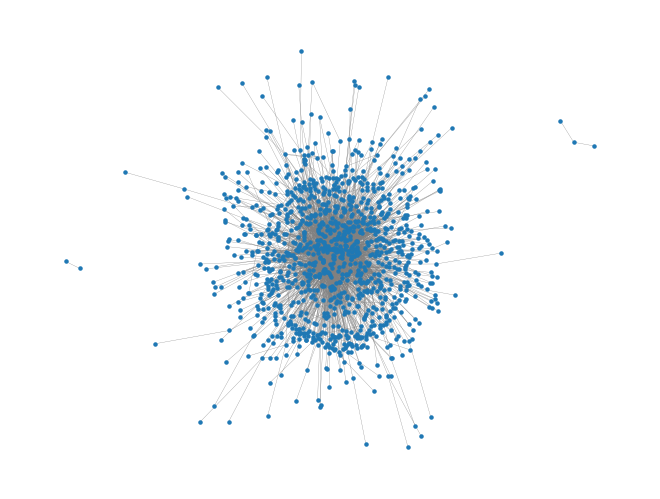

In [32]:
# NetworkX library has many options to plot a graph, see documentation to finetune visualization
# https://networkx.org/documentation/stable/reference/drawing.html
nx.draw(g, node_size=5, edge_color='gray', width=0.2)

In [33]:
# Geolocations could be plotted differently, one way is Basemap
# Node coordinates have to be accessed as lists

coord1, coord2 = [], []
for n in g.nodes:
    n = g.nodes[n]
    if 'geojson' in n and 'loc' in n['geojson']:
        coord2.append(float(n['geojson']['loc'].split(',')[0]))
        coord1.append(float(n['geojson']['loc'].split(',')[1]))
display(coord1[:3], coord2[:3])

[151.2073, -79.9748, 2.3768]

[-33.8678, 32.8546, 51.0344]

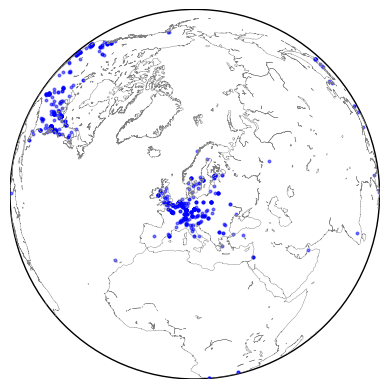

In [34]:
m = Basemap(projection='ortho', lat_0=55, lon_0=13, resolution='l')
m.drawcoastlines(linewidth=0.3, color='gray')
m.scatter(coord1, coord2, color='blue', s=3.5, 
          alpha=0.5, cmap='RdBu_r', latlon=True)